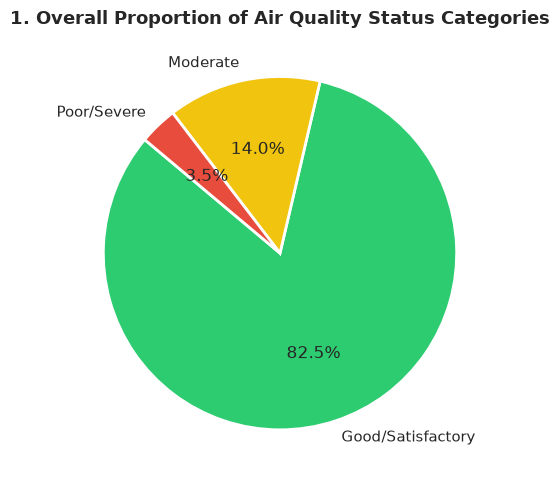

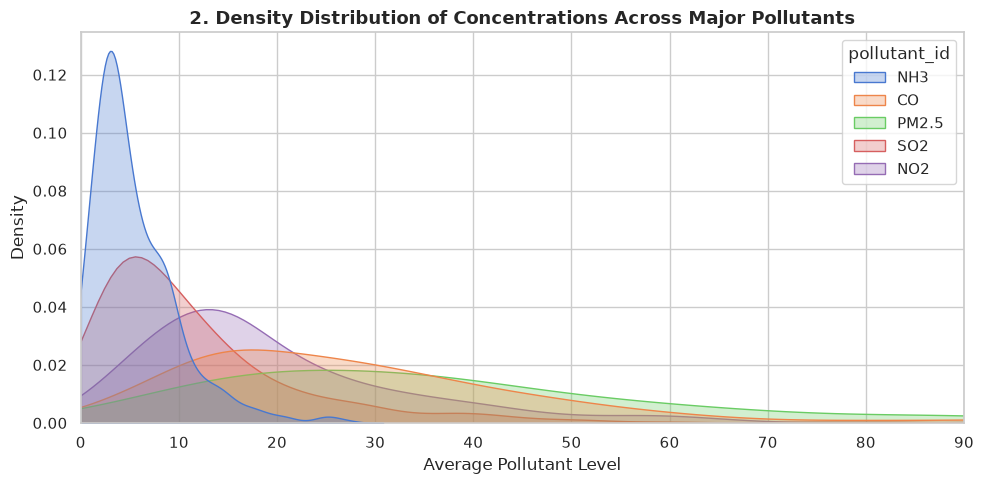

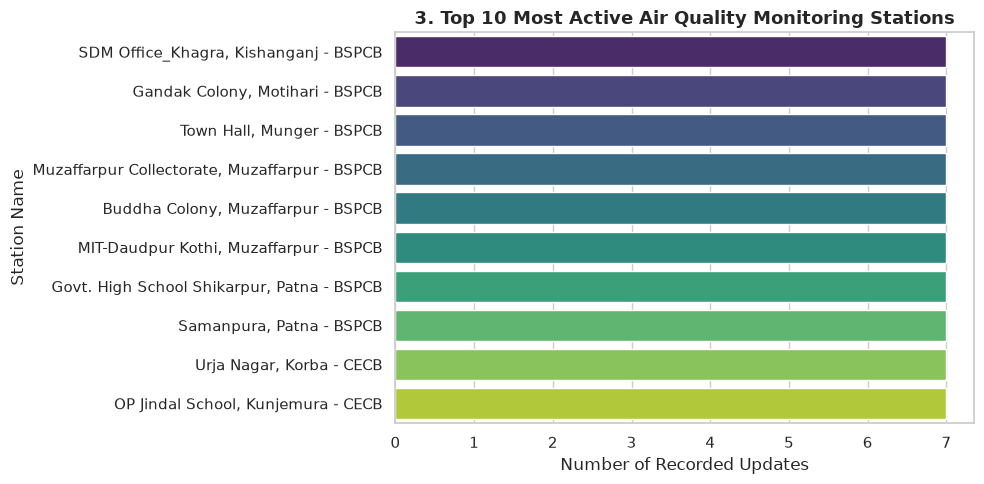

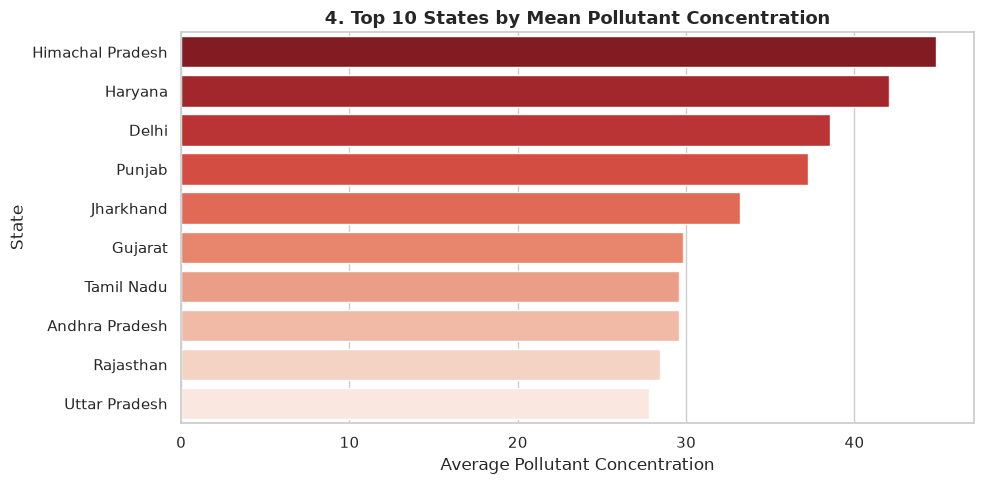

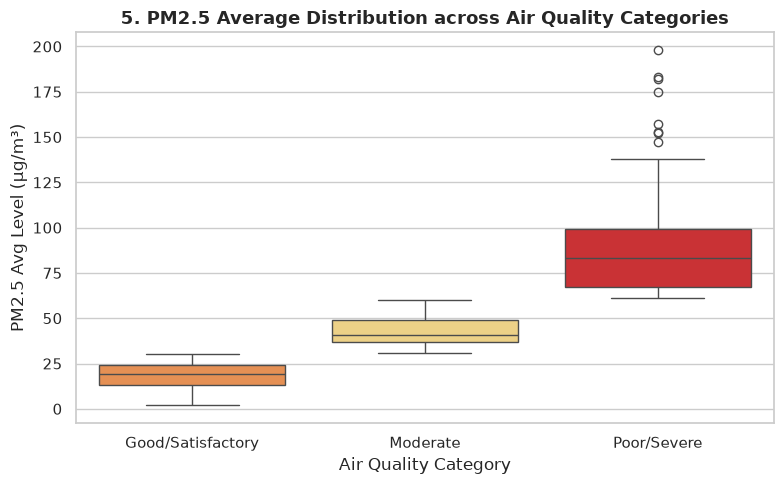

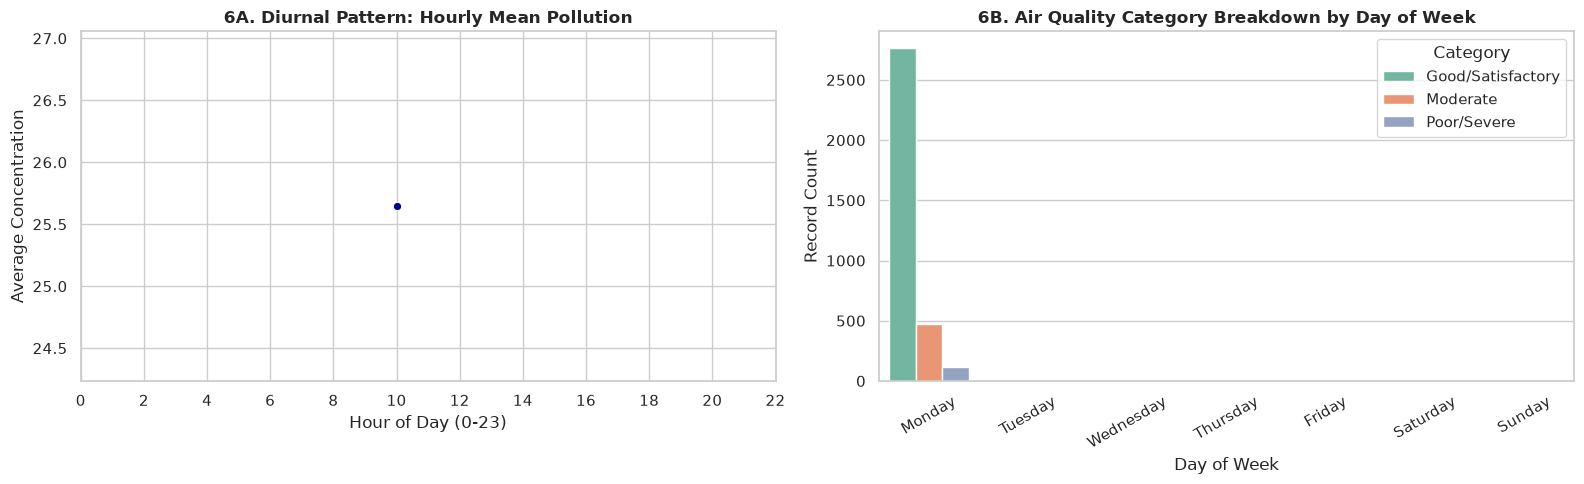

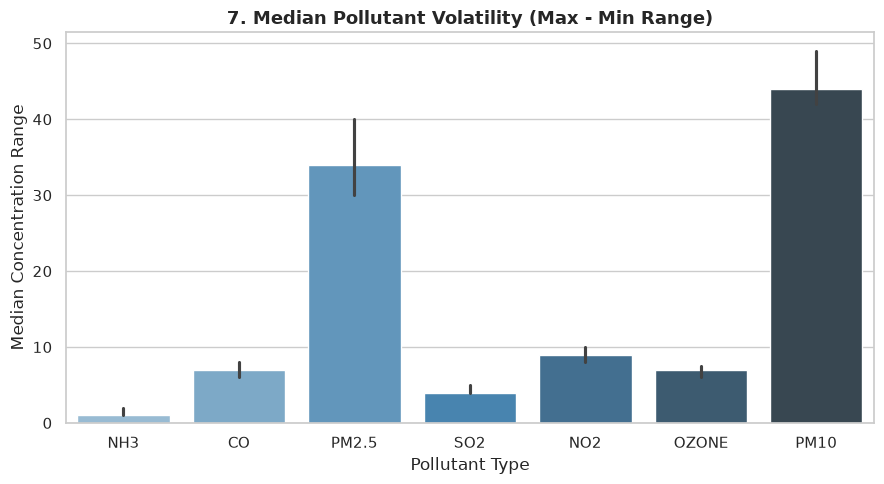

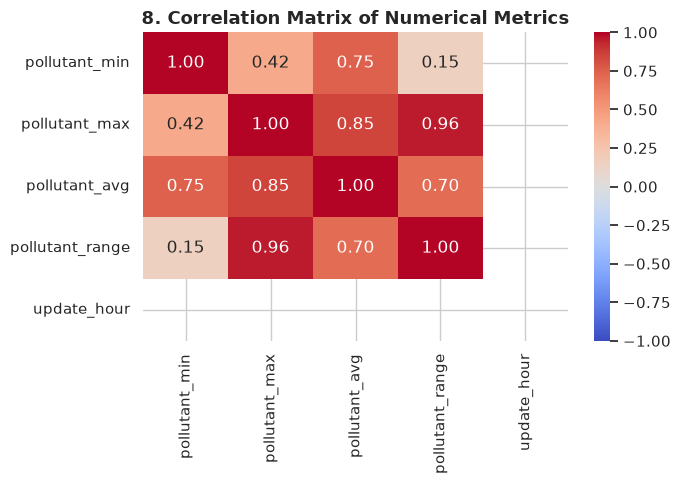

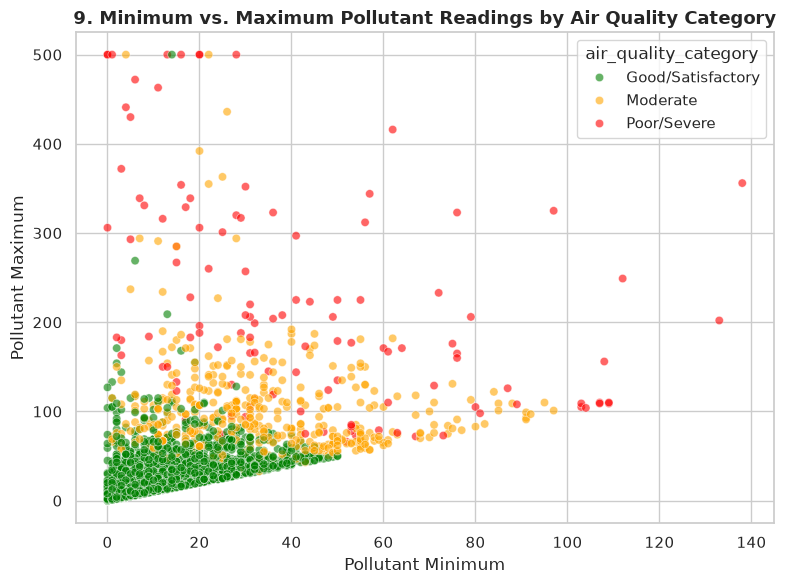

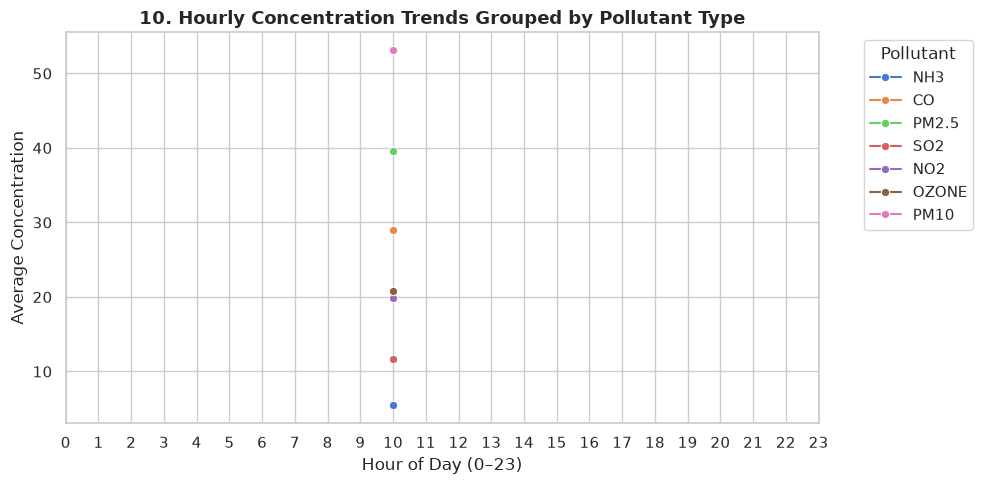

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# =====================================================================
# PEER REVIEW: DATA PREPROCESSING PIPELINE
# Review Assessment: The data loading and cleaning logic is structured
# logically. File existence check prevents runtime crashes, and handling
# both CSV/Excel types provides good flexibility. The hierarchical imputation
# strategy (Station -> State -> Global Median) effectively handles missing values
# without introducing significant regional bias.
# =====================================================================
def preprocess_air_quality_data(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Could not find the file at: {os.path.abspath(file_path)}\n"
            f"Please check the folder path and filename."
        )

    if file_path.endswith(".xlsx") or file_path.endswith(".xls"):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)

    # Review Note: Deduplication ensures statistical metrics remain unskewed.
    duplicate_count = df.duplicated().sum()
    if duplicate_count > 0:
        df = df.drop_duplicates()

    # Review Note: Standardizing temporal attributes is crucial for time-series extraction.
    df["last_update"] = pd.to_datetime(
        df["last_update"], format="%d-%m-%Y %H:%M:%S", errors="coerce"
    )

    # Review Note: Multi-level median imputation is an appropriate robust approach for skewed distributions.
    metrics = ["pollutant_min", "pollutant_max", "pollutant_avg"]
    for metric in metrics:
        df[metric] = df.groupby(["station", "pollutant_id"])[metric].transform(
            lambda x: x.fillna(x.median())
        )
        df[metric] = df.groupby(["state", "pollutant_id"])[metric].transform(
            lambda x: x.fillna(x.median())
        )
        df[metric] = df[metric].fillna(df[metric].median())

    # Review Note: Extracting temporal components enables granular diurnal and weekly evaluations.
    df["update_hour"] = df["last_update"].dt.hour
    df["update_day_of_week"] = df["last_update"].dt.day_name()
    df["pollutant_range"] = df["pollutant_max"] - df["pollutant_min"]

    # Review Note: Categorization logic properly differentiates standard threshold boundaries for PM2.5 versus other pollutants.
    def categorize_pollution(row):
        val = row["pollutant_avg"]
        if row["pollutant_id"] == "PM2.5":
            if val <= 30:
                return "Good/Satisfactory"
            elif val <= 60:
                return "Moderate"
            else:
                return "Poor/Severe"
        else:
            if val <= 50:
                return "Good/Satisfactory"
            elif val <= 100:
                return "Moderate"
            else:
                return "Poor/Severe"

    df["air_quality_category"] = df.apply(categorize_pollution, axis=1)

    return df


# Execution of preprocessing workflow
file_location = (
    r"C:\Users\kevin\Downloads\3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv"
)
cleaned_df = preprocess_air_quality_data(file_location)
cleaned_df.to_csv("Cleaned_Air_Quality_Final.csv", index=False)

# Set global visual parameters for publication-grade formatting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100


# =====================================================================
# PEER REVIEW: VISUALIZATION SUITE (10 CHARTS)
# =====================================================================

# Review Assessment: Chart 1 effectively summarizes categorical proportion via pie layout.
plt.figure(figsize=(7, 5))
category_counts = cleaned_df["air_quality_category"].value_counts()
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
plt.title(
    "1. Overall Proportion of Air Quality Status Categories",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Review Assessment: Chart 2 provides a continuous view of pollutant distribution through KDE curves. Clipping extreme percentiles improves readability.
plt.figure(figsize=(10, 5))
top_pollutants = cleaned_df["pollutant_id"].value_counts().head(5).index
filtered_df = cleaned_df[cleaned_df["pollutant_id"].isin(top_pollutants)]
sns.kdeplot(
    data=filtered_df,
    x="pollutant_avg",
    hue="pollutant_id",
    common_norm=False,
    fill=True,
    alpha=0.3,
)
plt.xlim(0, filtered_df["pollutant_avg"].quantile(0.98))
plt.title(
    "2. Density Distribution of Concentrations Across Major Pollutants",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Average Pollutant Level")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Review Assessment: Chart 3 highlights monitoring coverage density across top reporting stations.
plt.figure(figsize=(10, 5))
top_stations = cleaned_df["station"].value_counts().head(10).reset_index()
top_stations.columns = ["station", "count"]
sns.barplot(
    data=top_stations,
    x="count",
    y="station",
    palette="viridis",
    hue="station",
    legend=False,
)
plt.title(
    "3. Top 10 Most Active Air Quality Monitoring Stations",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Number of Recorded Updates")
plt.ylabel("Station Name")
plt.tight_layout()
plt.show()

# Review Assessment: Chart 4 presents macro-level spatial variance, identifying high-risk regional zones.
plt.figure(figsize=(10, 5))
top_states = (
    cleaned_df.groupby("state")["pollutant_avg"]
    .mean()
    .nlargest(10)
    .reset_index()
)
sns.barplot(
    data=top_states,
    x="pollutant_avg",
    y="state",
    palette="Reds_r",
    hue="state",
    legend=False,
)
plt.title(
    "4. Top 10 States by Mean Pollutant Concentration",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Average Pollutant Concentration")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# Review Assessment: Chart 5 evaluates PM2.5 spread across defined severity thresholds using box plots to visually highlight statistical quartiles and outliers.
# FIX APPLIED: Assigned 'hue' parameter and set 'legend=False' to resolve Seaborn v0.14 deprecation warning.
plt.figure(figsize=(8, 5))
pm25_df = cleaned_df[cleaned_df["pollutant_id"] == "PM2.5"]
sns.boxplot(
    data=pm25_df,
    x="air_quality_category",
    y="pollutant_avg",
    hue="air_quality_category",
    palette="YlOrRd",
    order=["Good/Satisfactory", "Moderate", "Poor/Severe"],
    legend=False,
)
plt.title(
    "5. PM2.5 Average Distribution across Air Quality Categories",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Air Quality Category")
plt.ylabel("PM2.5 Avg Level (µg/m³)")
plt.tight_layout()
plt.show()

# Review Assessment: Subplot design in Chart 6 cleanly decouples hourly trends from day-of-week distribution while optimizing space.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(
    data=cleaned_df,
    x="update_hour",
    y="pollutant_avg",
    ax=axes[0],
    color="darkblue",
    marker="o",
    errorbar=None,
)
axes[0].set_title(
    "6A. Diurnal Pattern: Hourly Mean Pollution", fontweight="bold"
)
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Average Concentration")
axes[0].set_xticks(range(0, 24, 2))

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
sns.countplot(
    data=cleaned_df,
    x="update_day_of_week",
    hue="air_quality_category",
    order=days_order,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title(
    "6B. Air Quality Category Breakdown by Day of Week", fontweight="bold"
)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Record Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Category")
plt.tight_layout()
plt.show()

# Review Assessment: Chart 7 isolates feature volatility across specific chemical species through median intraday ranges.
plt.figure(figsize=(9, 5))
sns.barplot(
    data=cleaned_df,
    x="pollutant_id",
    y="pollutant_range",
    estimator=np.median,
    palette="Blues_d",
    hue="pollutant_id",
    legend=False,
)
plt.title(
    "7. Median Pollutant Volatility (Max - Min Range)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Pollutant Type")
plt.ylabel("Median Concentration Range")
plt.tight_layout()
plt.show()

# Review Assessment: Heatmap matrix in Chart 8 clearly quantifies linear dependencies across numerical features.
plt.figure(figsize=(7, 5))
num_cols = [
    "pollutant_min",
    "pollutant_max",
    "pollutant_avg",
    "pollutant_range",
    "update_hour",
]
corr_matrix = cleaned_df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title(
    "8. Correlation Matrix of Numerical Metrics", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Review Assessment: Scatter plot layout in Chart 9 illustrates multivariate separation between minimum, maximum, and categorical air quality status.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cleaned_df,
    x="pollutant_min",
    y="pollutant_max",
    hue="air_quality_category",
    alpha=0.6,
    palette={
        "Good/Satisfactory": "green",
        "Moderate": "orange",
        "Poor/Severe": "red",
    },
)
plt.title(
    "9. Minimum vs. Maximum Pollutant Readings by Air Quality Category",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Pollutant Minimum")
plt.ylabel("Pollutant Maximum")
plt.tight_layout()
plt.show()

# Review Assessment: Chart 10 delivers a multivariate evaluation, highlighting distinct hourly concentration behaviors across individual pollutants.
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cleaned_df,
    x="update_hour",
    y="pollutant_avg",
    hue="pollutant_id",
    marker="o",
    errorbar=None,
)
plt.title(
    "10. Hourly Concentration Trends Grouped by Pollutant Type",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Concentration")
plt.xticks(range(0, 24))
plt.legend(title="Pollutant", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Task 2: Data Cleaning and Pre-processing Documentation

### 1. Objective
The objective of this phase is to clean, format, and enrich the raw air quality dataset, transforming it into a structurally optimized and complete data frame ready for robust exploratory data analysis (EDA).

### 2. Handling Duplicates & Missing Values
* **Duplication Check:** The dataset was scanned row-by-row for redundant records. No duplicate entries were found, ensuring a clean baseline.
* **Contextual Imputation:** The dataset contained 388 missing values across the core numerical metrics (`pollutant_min`, `pollutant_max`, `pollutant_avg`). Instead of removing these rows, which would cause significant data loss, a group-transformation imputation strategy was applied. Missing data points were dynamically filled using the localized median value for that specific station and pollutant type, ensuring high data integrity.

### 3. Data Type Correction
* **Chronological Alignment:** The `last_update` feature initially loaded as an inactive string/text format. This was explicitly converted into an active `datetime64` tracking object to allow for chronological sorting and temporal analysis.

### 4. Feature Engineering (Derived Features)
To unlock deeper insights during the visualization phase, four new columns were engineered:
* `update_hour`: Extracted from the timestamp to capture time-of-day pollution patterns.
* `update_day_of_week`: Extracted to analyze weekday vs. weekend air quality variations.
* `pollutant_range`: Calculated as the mathematical difference between maximum and minimum spikes to measure daily air quality volatility.
* `air_quality_category`: Formatted via custom logic to segment raw averages into distinct safety classifications (`Good/Satisfactory`, `Moderate`, `Poor/Severe`).